# Category Analysis

Author: Tim Berger 
Date: 20.5.2026

#### Introduction
The Zürich wie neu website allows the residents of Zürich to report damage and defects of the infrastructure of the city. 
Reports are sorted in different categories, such as waste or graphity. 
By identifying the categories with the most reports, we can determine what disturbs the residents of Zurich the most or which category suffers the most damage.

#### Research Question: 
Where do the ilegal desposed waste and littering reports in Züri wie neu cluster within the city?

#### Requirements
To be able to run this code, use the environment sds210 located in the github repository of this project.

### Import Required Packages and Scripts

In [65]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
from scipy import stats

import notebook_utils

### Access and load data via API (züri wie neu, neighbourhoods, income)

In [66]:
# the notebook_utils file contains all the functions to load the required data from the website of the canton of zurich
# if a dataset failed to load, the corresponding url in the notebook utils file should be checked

zwn_gdf_raw = notebook_utils.import_zwn_data()


Data züri wie neu loaded sugessfull


### Clean and Filter the Data

In [67]:
# filter for the required columns
zwn_df = zwn_gdf_raw[["service_request_id", "title", "service_name", "requested_datetime"]].copy()

### Agregate and Normalize

- agregate the data to have the number of reports per category

In [68]:
#count the reports per category
zwn_categories = zwn_df["service_name"].value_counts().copy().to_frame()

#rename the column and index
zwn_categories = zwn_categories.rename(columns={"count":"count_reports"}, index={"service_name": "category"})


- normalize counts per year

In [69]:
# calculate the time between the oldest and newest report
time_diff = max(zwn_df["requested_datetime"])- min(zwn_df["requested_datetime"])

#add a column with the reports per year
zwn_categories["reports_per_day"] = round(zwn_categories["count_reports"] / time_diff.days, 2)

zwn_categories.head(4)

,count_reports,reports_per_day
service_name,,
Abfall/Sammelstelle,27585,5.73
Signalisation/Lichtsignal,11036,2.29
Strasse/Trottoir/Platz,9903,2.06
Grünflächen/Spielplätze,7288,1.52


### Plot Data

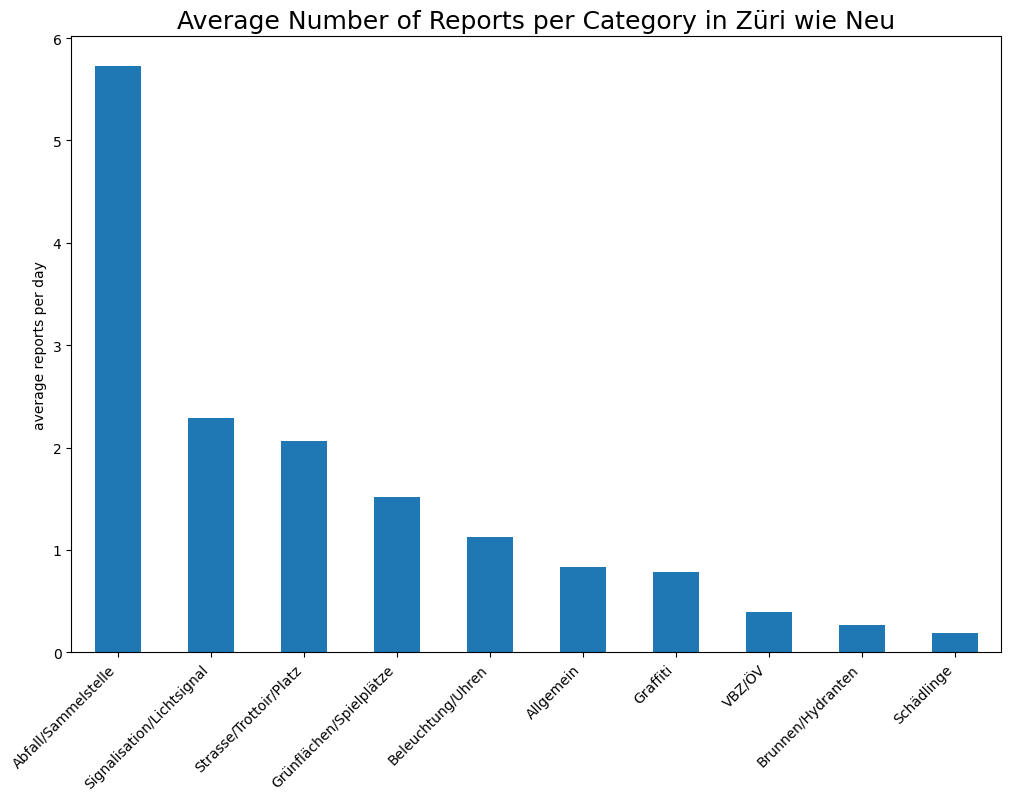

In [70]:
fig, ax = plt.subplots(figsize = (12,8))

#plot the reports per category as a barplot
zwn_categories["reports_per_day"].plot(kind="bar", ax=ax,
                                       xlabel="",
                                       ylabel="average reports per day")

#set title
ax.set_title("Average Number of Reports per Category in Züri wie Neu", fontsize=18)

#rotate neighbourhood labels on the x axis
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, horizontalalignment="right");